# Training Model Pengenalan Wajah - Iris Short Term 1

Notebook ini melatih model **deep learning** untuk mengenali wajah 7 orang menggunakan arsitektur **ResNet-50** dengan teknik **Transfer Learning** (PyTorch).

---

##  Import Library

Mengimpor semua library yang dibutuhkan:
- `numpy`, `pandas` → manipulasi data
- `matplotlib`, `seaborn` → visualisasi
- `sklearn` → split data, metrik evaluasi, class weights
- `torch`, `torchvision` → deep learning & pretrained model
- `PIL` → membaca gambar

In [1]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm.auto import tqdm

## Konfigurasi Hyperparameter & Path Dataset

Mendefinisikan seluruh konfigurasi eksperimen dalam satu tempat agar mudah diubah:

| Parameter | Nilai | Keterangan |
|---|---|---|
| `IMG_SIZE` | 299 | Ukuran input gambar (px) |
| `BATCH_SIZE` | 16 | Jumlah gambar per batch |
| `N_SPLITS` | 5 | Jumlah fold K-Fold |
| `EPOCHS_HEAD` | 5 | Epoch untuk melatih head saja |
| `EPOCHS_FINE` | 10 | Epoch untuk fine-tuning seluruh model |
| `LR_HEAD` | 1e-3 | Learning rate fase head |
| `LR_FINE` | 1e-5 | Learning rate fase fine-tuning (sangat kecil) |
| `DEVICE` | cuda/cpu | Otomatis memilih GPU jika tersedia |

In [2]:
# GANTI PATH DATASET KAMU
DATASET_DIR = "/kaggle/input/datasets/iwayansatya/iris-shortterm-1/Crop Wajah"   # atau "/content/dataset"

IMG_SIZE = 299
BATCH_SIZE = 16
NUM_WORKERS = 0
N_SPLITS = 5
EPOCHS_HEAD = 5
EPOCHS_FINE = 10
LR_HEAD = 1e-3
LR_FINE = 1e-5
SEED = 42
MIN_IMAGES_PER_CLASS = 2

VALID_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## Seed Everything

Mengunci semua sumber keacakan (`random`, `numpy`, `torch`) dengan seed yang sama agar **eksperimen dapat direproduksi** — menjalankan ulang notebook akan menghasilkan hasil yang identik.

In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

## Membangun DataFrame Dataset

Fungsi `build_dataframe()` menelusuri folder dataset secara rekursif:
- Setiap **subfolder = satu kelas** (nama orang)
- Setiap **file gambar** dalam subfolder dicatat path-nya

Hasilnya: DataFrame dengan kolom `filepath` dan `label` berisi **945 gambar dari 7 kelas**.

In [4]:
def build_dataframe(dataset_dir):
    rows = []
    class_names = sorted([
        d for d in os.listdir(dataset_dir)
        if os.path.isdir(os.path.join(dataset_dir, d))
    ])
    
    for cls in class_names:
        class_dir = os.path.join(dataset_dir, cls)
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(VALID_EXTS):
                rows.append({
                    "filepath": os.path.join(class_dir, fname),
                    "label": cls
                })
    return pd.DataFrame(rows)

df = build_dataframe(DATASET_DIR)
print("Total images:", len(df))
print("Total classes:", df["label"].nunique())
df.head()

Total images: 945
Total classes: 7


,filepath,label
0,/kaggle/input/datasets/iwayansatya/iris-shortt...,Ashif
1,/kaggle/input/datasets/iwayansatya/iris-shortt...,Ashif
2,/kaggle/input/datasets/iwayansatya/iris-shortt...,Ashif
3,/kaggle/input/datasets/iwayansatya/iris-shortt...,Ashif
4,/kaggle/input/datasets/iwayansatya/iris-shortt...,Ashif


## Filter Kelas & Distribusi Data

Menghapus kelas yang memiliki terlalu sedikit gambar (< `MIN_IMAGES_PER_CLASS = 2`).

Distribusi data per kelas:
- **Ashif**: 193 gambar
- **Satya**: 188 gambar  
- **Marcell**: 169 gambar
- **Christo**: 143 gambar
- **Devian**: 123 gambar
- **Patrick**: 74 gambar
- **Naufal**: 55 gambar


In [5]:
class_counts = df["label"].value_counts().sort_index()
print(class_counts)

valid_classes = class_counts[class_counts >= MIN_IMAGES_PER_CLASS].index.tolist()
df = df[df["label"].isin(valid_classes)].reset_index(drop=True)

print("\nSetelah filter:")
print("Total images:", len(df))
print("Total classes:", df["label"].nunique())

label
Ashif      193
Christo    143
Devian     123
Marcell    169
Naufal      55
Patrick     74
Satya      188
Name: count, dtype: int64

Setelah filter:
Total images: 945
Total classes: 7


## Visualisasi Distribusi Kelas

Menampilkan bar chart jumlah gambar per kelas agar ketimpangan distribusi data mudah terlihat secara visual.

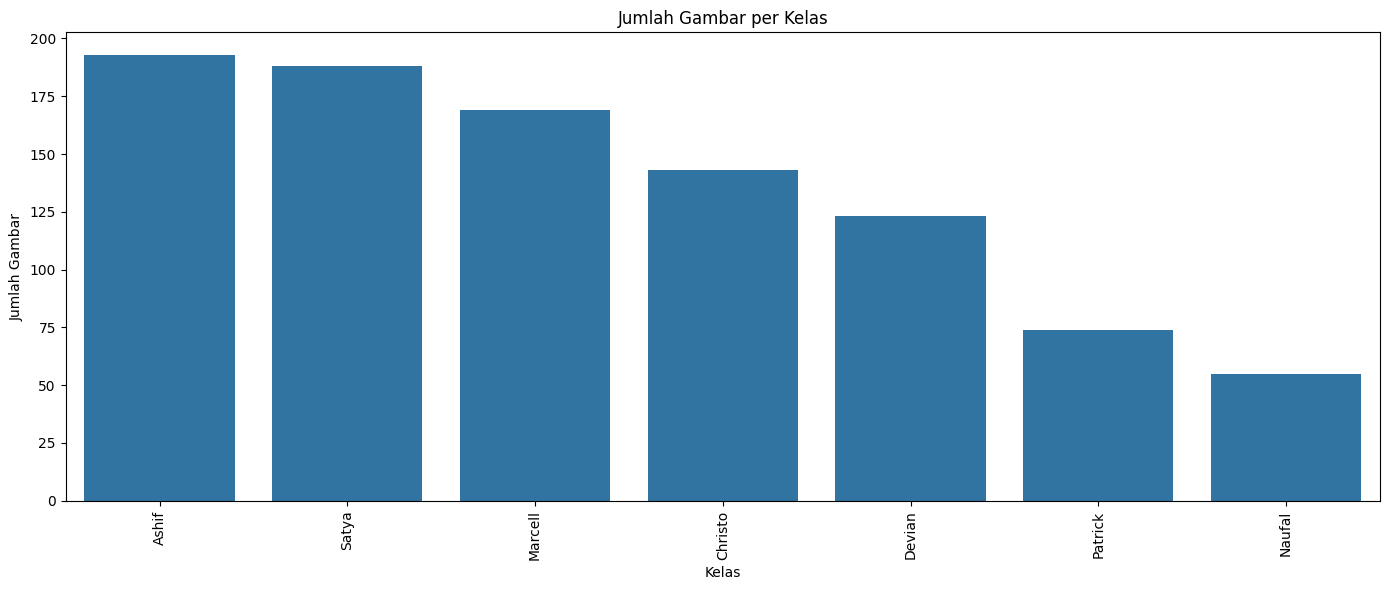

,num_images
label,
Ashif,193
Satya,188
Marcell,169
Christo,143
Devian,123
Patrick,74
Naufal,55


In [6]:
plt.figure(figsize=(14, 6))
counts = df["label"].value_counts().sort_values(ascending=False)

sns.barplot(x=counts.index, y=counts.values)
plt.title("Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

display(counts.to_frame("num_images"))

## Train / Test Split

Membagi dataset menjadi:
- **Train set**: 75% → 708 gambar (untuk melatih model)
- **Test set**: 25% → 237 gambar (untuk evaluasi akhir)

Menggunakan `stratify=df["label"]` agar proporsi kelas di train dan test **tetap seimbang**.

In [7]:
train_df, test_df = train_test_split(
    df,
    test_size=0.25,
    stratify=df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size :", len(test_df))

Train size: 708
Test size : 237


## Label Encoding

Mengonversi nama kelas (string) menjadi indeks angka agar bisa diproses model:

```
Ashif=0, Christo=1, Devian=2, Marcell=3, Naufal=4, Patrick=5, Satya=6
```

Dua dictionary dibuat: `class_to_idx` (nama→angka) dan `idx_to_class` (angka→nama) untuk keperluan prediksi.

In [8]:
class_names = sorted(train_df["label"].unique())
num_classes = len(class_names)

class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

train_df["class_idx"] = train_df["label"].map(class_to_idx)
test_df["class_idx"] = test_df["label"].map(class_to_idx)

print("Num classes:", num_classes)
print(class_to_idx)

Num classes: 7
{'Ashif': 0, 'Christo': 1, 'Devian': 2, 'Marcell': 3, 'Naufal': 4, 'Patrick': 5, 'Satya': 6}


## Transformasi Gambar (Augmentasi)

Dua pipeline transform disiapkan:

**`train_transform`** (augmentasi agresif untuk mencegah overfitting):
- Resize ke 320×320, lalu CenterCrop ke 299×299
- Random horizontal flip, rotasi ±15°
- Color jitter (brightness, contrast, saturation)
- Random affine (translasi + scaling)
- Random grayscale & Gaussian blur
- Normalisasi ImageNet (`mean=[0.485, 0.456, 0.406]`)

**`valid_transform`** (tanpa augmentasi untuk evaluasi konsisten):
- Hanya resize, crop, dan normalisasi

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((320, 320)),                          # sedikit lebih besar
    transforms.CenterCrop(299),                             # crop ke target size
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),                          # naik sedikit dari 10
    transforms.ColorJitter(brightness=0.2, contrast=0.2,   # sedikit lebih variatif
                           saturation=0.1, hue=0.05),
    transforms.RandomAffine(degrees=0,
                            translate=(0.10, 0.10),         # sedikit lebih luas
                            scale=(0.90, 1.10)),
    transforms.RandomGrayscale(p=0.05),                    # tambahan
    transforms.GaussianBlur(kernel_size=3,                 # tambahan
                            sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

valid_transform = transforms.Compose([
    transforms.Resize((320, 320)),   # sama, konsisten
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

## Custom Dataset Class

`FaceDataset` adalah subclass PyTorch `Dataset` yang:
1. Menyimpan DataFrame berisi path gambar dan label
2. Membuka gambar dari disk saat dipanggil (`__getitem__`)
3. Menerapkan transformasi yang diberikan
4. Mengembalikan pasangan `(image_tensor, label_int)`

In [10]:
class FaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "filepath"]
        label = int(self.df.loc[idx, "class_idx"])
        
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

## Fungsi DataLoader

`make_dataloader()` membungkus `FaceDataset` ke dalam `DataLoader` yang mengurus:
- **Batching**: mengelompokkan gambar per batch
- **Shuffling**: mengacak urutan data saat training
- **pin_memory**: mempercepat transfer data ke GPU

In [11]:
def make_dataloader(df_part, transform, shuffle=False):
    dataset = FaceDataset(df_part, transform=transform)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )
    return loader

## Arsitektur Model (ResNet-50)

Menggunakan **ResNet-50** pretrained ImageNet dengan modifikasi pada *fully connected layer* terakhir:

```
ResNet-50 Backbone (pretrained)
        ↓
   Linear(2048 → 512)
        ↓
      ReLU
        ↓
   Dropout(p=0.4)   ← mencegah overfitting
        ↓
   Linear(512 → 7)  ← output 7 kelas
```

Saat `freeze_backbone=True`, semua parameter backbone **dibekukan** — hanya layer FC baru yang dilatih (fase head training).

In [12]:
def build_model(num_classes, freeze_backbone=True):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, num_classes)
    )
    
    return model

## Fungsi Training & Evaluasi Per Epoch

**`train_one_epoch()`**: melatih model satu epoch penuh
- Forward pass → hitung loss → backward pass → update bobot
- Mengumpulkan prediksi untuk menghitung accuracy & F1-Macro

**`eval_one_epoch()`**: mengevaluasi model tanpa update gradient
- Menggunakan `@torch.no_grad()` untuk efisiensi memori
- Mengembalikan loss, accuracy, F1, serta semua label & prediksi

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, epoch_acc, epoch_f1


@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, epoch_acc, epoch_f1, all_labels, all_preds

## Early Stopping

Menghentikan training otomatis jika metrik validasi tidak membaik selama `patience` epoch berturut-turut.

- Mode `max`: berhenti jika val F1 tidak naik (dipakai di sini)
- Menyimpan model terbaik setiap kali ada peningkatan
- Mencegah overfitting sekaligus menghemat waktu komputasi

In [14]:
class EarlyStopping:
    def __init__(self, patience=4, mode="max", delta=0.0):
        self.patience = patience
        self.mode = mode
        self.delta = delta
        self.best_score = None
        self.counter = 0
        self.early_stop = False
        
    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
            return True
        
        improved = (score > self.best_score + self.delta) if self.mode == "max" else (score < self.best_score - self.delta)
        
        if improved:
            self.best_score = score
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
            return False

## Training Utama: 5-Fold Cross Validation

Inti dari notebook ini. Setiap fold menjalankan **2 tahap training**:

### Stage 1 — Head Training
- Backbone **dibekukan**, hanya FC layer yang dilatih
- Learning rate besar (`1e-3`) → belajar cepat dari fitur pretrained
- Maks. 5 epoch dengan early stopping (patience=3)

### Stage 2 — Fine-tuning
- Seluruh backbone **dibuka** (`unfreeze`)
- Learning rate sangat kecil (`1e-5`) → menyesuaikan fitur secara halus
- Maks. 10 epoch dengan early stopping

> **Class weights** digunakan pada `CrossEntropyLoss` untuk menangani ketimpangan jumlah gambar antar kelas.

FOLD 1/5
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 234MB/s]



[Stage 1] Train classifier head


  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

...

  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

Epoch 5/10 | train_loss=0.0080 train_acc=0.9982 train_f1=0.9972 | val_loss=0.0019 val_acc=1.0000 val_f1=1.0000
Early stopping at stage 2


  0%|          | 0/9 [00:00<?, ?it/s]


[Fold 1] best_saved_f1=1.0000
[Fold 1] val_acc=1.0000, val_f1_macro=1.0000


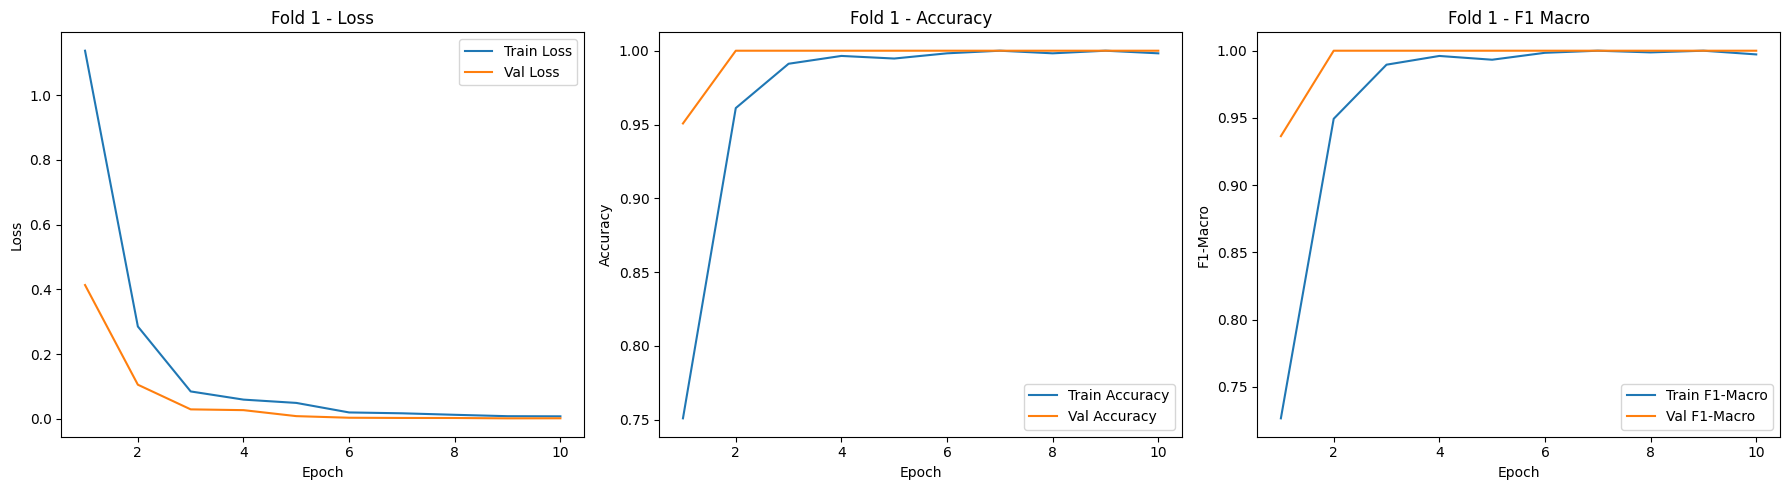

FOLD 2/5

[Stage 1] Train classifier head


  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

Epoch 1/5 | train_loss=1.2004 train_acc=0.6961 train_f1=0.6609 | val_loss=0.4403 val_acc=0.9718 val_f1=0.9617


  0%|          | 0/36 [00:00<?, ?it/s]

...

  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

Epoch 5/10 | train_loss=0.0122 train_acc=1.0000 train_f1=1.0000 | val_loss=0.0029 val_acc=1.0000 val_f1=1.0000
Early stopping at stage 2


  0%|          | 0/9 [00:00<?, ?it/s]


[Fold 2] best_saved_f1=1.0000
[Fold 2] val_acc=1.0000, val_f1_macro=1.0000


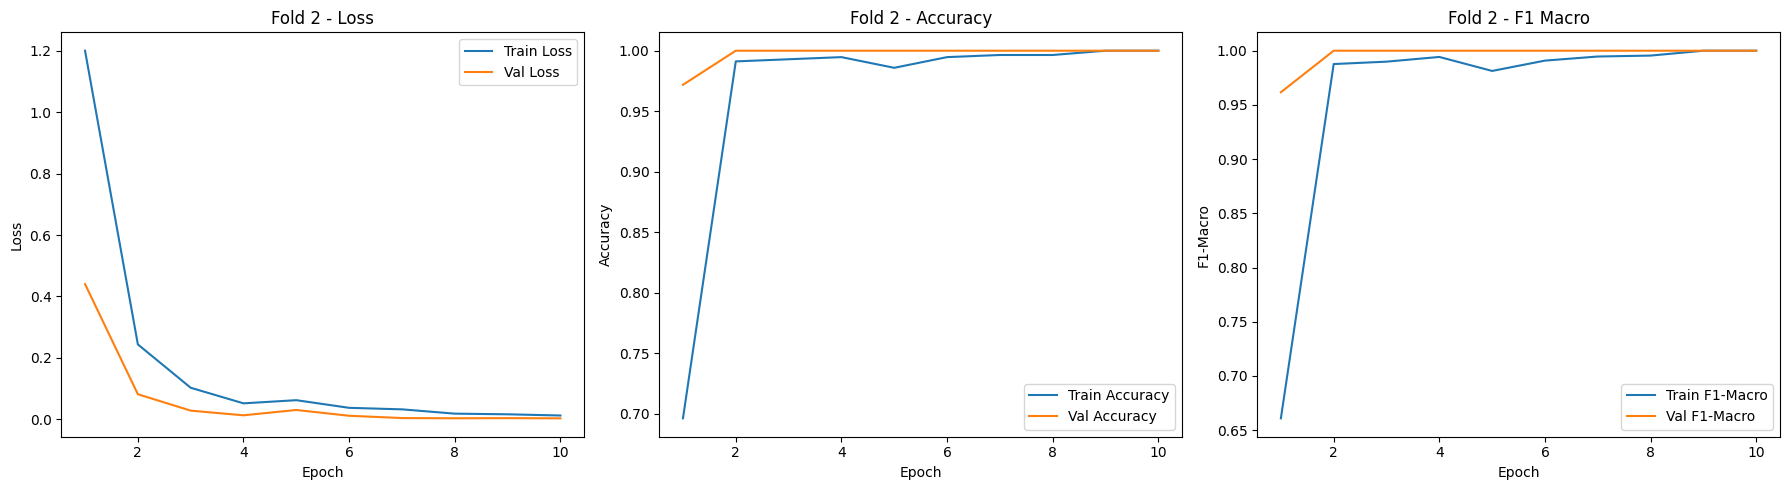

FOLD 3/5

[Stage 1] Train classifier head


  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

Epoch 1/5 | train_loss=1.1199 train_acc=0.7650 train_f1=0.7237 | val_loss=0.2743 val_acc=1.0000 val_f1=1.0000


  0%|          | 0/36 [00:00<?, ?it/s]

...

  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

Epoch 5/10 | train_loss=0.0106 train_acc=0.9982 train_f1=0.9984 | val_loss=0.0007 val_acc=1.0000 val_f1=1.0000
Early stopping at stage 2


  0%|          | 0/9 [00:00<?, ?it/s]


[Fold 3] best_saved_f1=1.0000
[Fold 3] val_acc=1.0000, val_f1_macro=1.0000


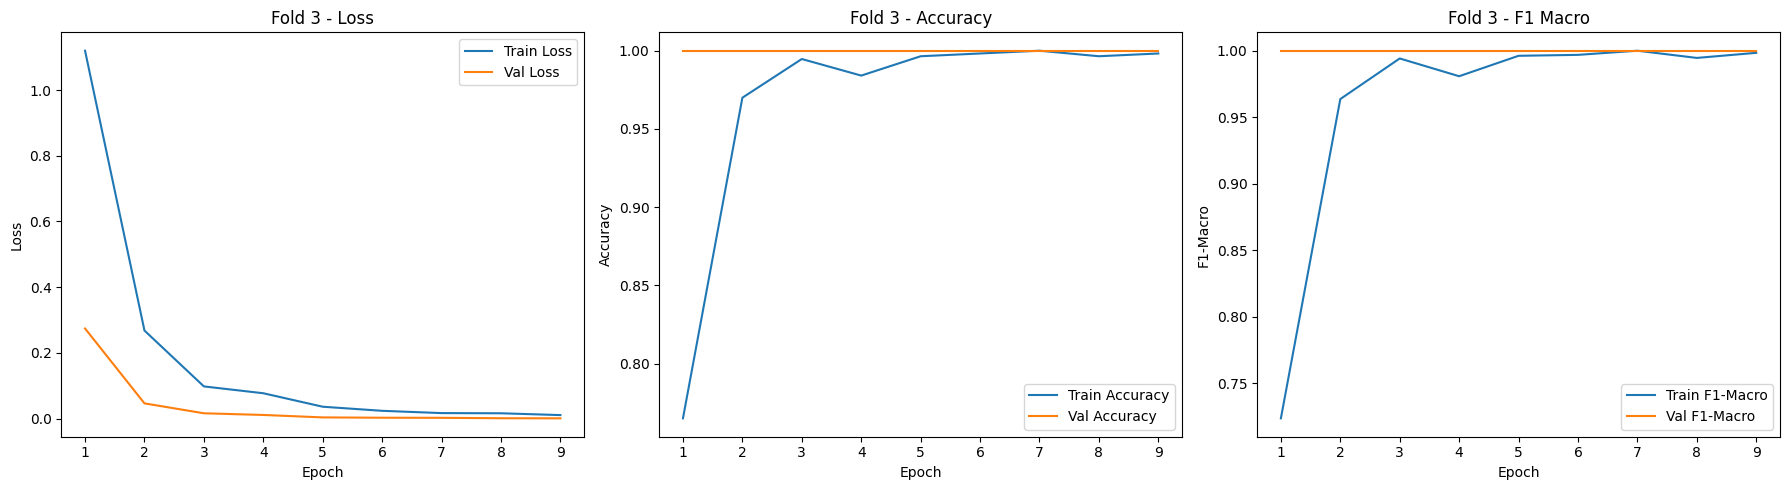

FOLD 4/5

[Stage 1] Train classifier head


  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

Epoch 1/5 | train_loss=1.1119 train_acc=0.7619 train_f1=0.7290 | val_loss=0.3045 val_acc=1.0000 val_f1=1.0000


  0%|          | 0/36 [00:00<?, ?it/s]

...

  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

Epoch 5/10 | train_loss=0.0111 train_acc=1.0000 train_f1=1.0000 | val_loss=0.0011 val_acc=1.0000 val_f1=1.0000
Early stopping at stage 2


  0%|          | 0/9 [00:00<?, ?it/s]


[Fold 4] best_saved_f1=1.0000
[Fold 4] val_acc=1.0000, val_f1_macro=1.0000


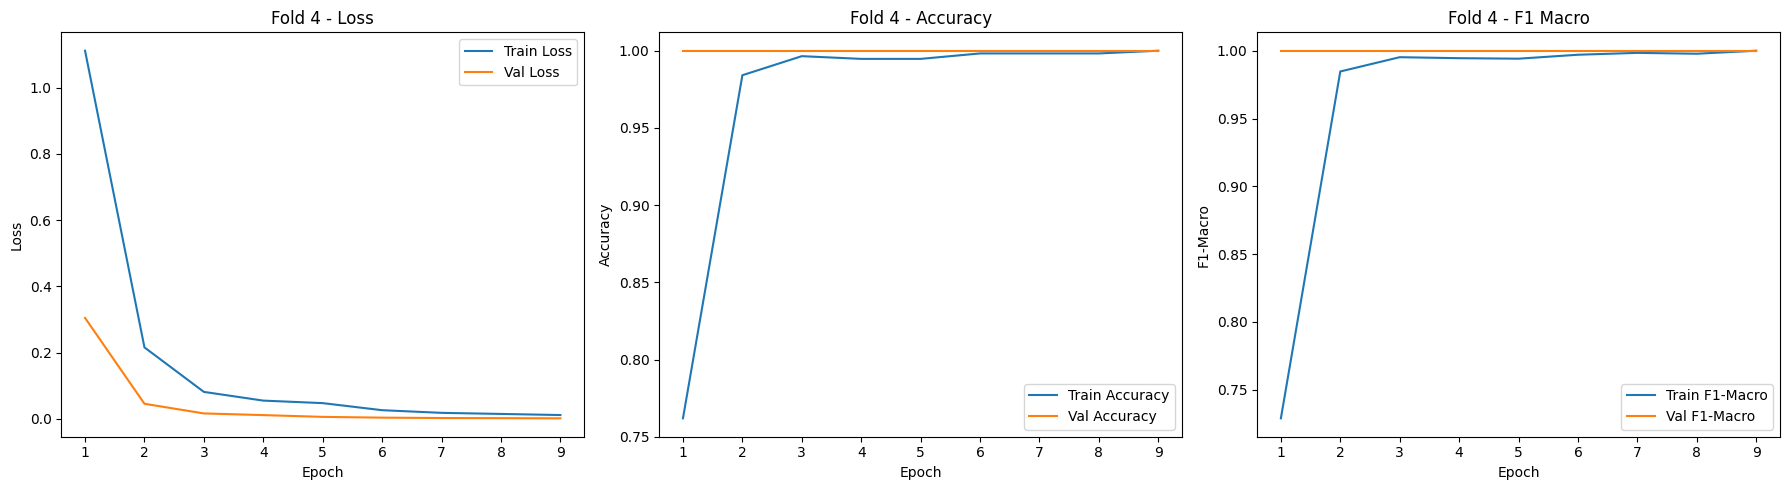

FOLD 5/5

[Stage 1] Train classifier head


  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

Epoch 1/5 | train_loss=1.2225 train_acc=0.7513 train_f1=0.6813 | val_loss=0.3564 val_acc=1.0000 val_f1=1.0000


  0%|          | 0/36 [00:00<?, ?it/s]

...

  0%|          | 0/36 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

Epoch 5/10 | train_loss=0.0094 train_acc=1.0000 train_f1=1.0000 | val_loss=0.0016 val_acc=1.0000 val_f1=1.0000
Early stopping at stage 2


  0%|          | 0/9 [00:00<?, ?it/s]


[Fold 5] best_saved_f1=1.0000
[Fold 5] val_acc=1.0000, val_f1_macro=1.0000


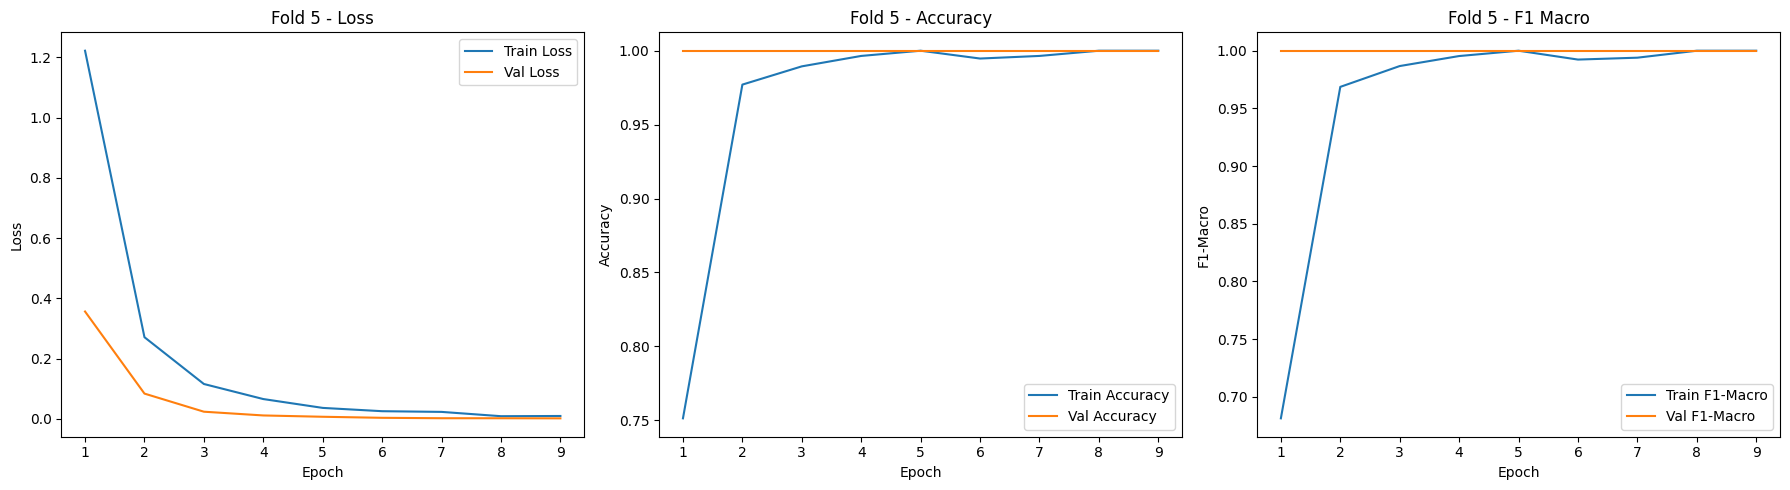

In [15]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

X = train_df["filepath"].values
y = train_df["class_idx"].values

fold_results = []
best_model_paths = []
all_fold_histories = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    print("=" * 90)
    print(f"FOLD {fold}/{N_SPLITS}")
    
    train_fold_df = train_df.iloc[tr_idx].copy().reset_index(drop=True)
    valid_fold_df = train_df.iloc[va_idx].copy().reset_index(drop=True)
    
    train_loader = make_dataloader(train_fold_df, train_transform, shuffle=True)
    valid_loader = make_dataloader(valid_fold_df, valid_transform, shuffle=False)
    
    # class weights
    y_train_fold = train_fold_df["class_idx"].values
    cls_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train_fold),
        y=y_train_fold
    )
    
    weight_tensor = torch.ones(num_classes, dtype=torch.float32)
    for cls_id, w in zip(np.unique(y_train_fold), cls_weights):
        weight_tensor[int(cls_id)] = float(w)
    weight_tensor = weight_tensor.to(DEVICE)
    
    # history per fold
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1": [],
        "val_f1": []
    }
    
    # build model
    model = build_model(num_classes=num_classes, freeze_backbone=True).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)
    optimizer = torch.optim.Adam(model.fc.parameters(), lr=LR_HEAD)
    
    best_path = f"best_fold_{fold}_full_model.pth"
    best_f1 = -1.0
    
    # ---------------------------
    # Stage 1: head training
    # ---------------------------
    early_stopper = EarlyStopping(patience=3, mode="max")
    print("\n[Stage 1] Train classifier head")
    
    for epoch in range(EPOCHS_HEAD):
        train_loss, train_acc, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE
        )
        val_loss, val_acc, val_f1, _, _ = eval_one_epoch(
            model, valid_loader, criterion, DEVICE
        )
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)
        
        print(
            f"Epoch {epoch+1}/{EPOCHS_HEAD} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} train_f1={train_f1:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}"
        )
        
        if early_stopper(val_f1):
            torch.save(model, best_path)
            best_f1 = val_f1
        
        if early_stopper.early_stop:
            print("Early stopping at stage 1")
            break
    
    # ---------------------------
    # Stage 2: fine tuning
    # ---------------------------
    print("\n[Stage 2] Fine tuning")
    
    for param in model.parameters():
        param.requires_grad = False
    
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True
    
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR_FINE
    )
    
    early_stopper = EarlyStopping(patience=4, mode="max")
    
    for epoch in range(EPOCHS_FINE):
        train_loss, train_acc, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE
        )
        val_loss, val_acc, val_f1, _, _ = eval_one_epoch(
            model, valid_loader, criterion, DEVICE
        )
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)
        
        print(
            f"Epoch {epoch+1}/{EPOCHS_FINE} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} train_f1={train_f1:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}"
        )
        
        if early_stopper(val_f1):
            torch.save(model, best_path)
            best_f1 = val_f1
        
        if early_stopper.early_stop:
            print("Early stopping at stage 2")
            break
    
    # ---------------------------
    # Final eval for this fold
    # ---------------------------
    best_model = torch.load(
        best_path,
        map_location=DEVICE,
        weights_only=False   # penting untuk full model pada PyTorch baru
    )
    best_model.to(DEVICE)
    best_model.eval()
    
    val_loss, val_acc, val_f1, val_true, val_pred = eval_one_epoch(
        best_model, valid_loader, criterion, DEVICE
    )
    
    print(f"\n[Fold {fold}] best_saved_f1={best_f1:.4f}")
    print(f"[Fold {fold}] val_acc={val_acc:.4f}, val_f1_macro={val_f1:.4f}")
    
    fold_results.append({
        "fold": fold,
        "val_accuracy": val_acc,
        "val_f1_macro": val_f1
    })
    
    best_model_paths.append({
        "fold": fold,
        "path": best_path,
        "val_f1_macro": val_f1
    })
    
    all_fold_histories.append({
        "fold": fold,
        "history": history
    })
    
    # line plot per fold
    epochs_range = range(1, len(history["train_loss"]) + 1)
    
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Fold {fold} - Loss")
    plt.legend()
    
    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs_range, history["val_acc"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Fold {fold} - Accuracy")
    plt.legend()
    
    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, history["train_f1"], label="Train F1-Macro")
    plt.plot(epochs_range, history["val_f1"], label="Val F1-Macro")
    plt.xlabel("Epoch")
    plt.ylabel("F1-Macro")
    plt.title(f"Fold {fold} - F1 Macro")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # cleanup ringan
    del model, best_model, train_loader, valid_loader
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## Hasil Evaluasi K-Fold

Merangkum hasil validasi semua fold ke dalam DataFrame.

| Fold | Val Accuracy | Val F1-Macro |
|------|-------------|-------------|
| 1    | 1.0         | 1.0         |
| 2    | 1.0         | 1.0         |
| 3    | 1.0         | 1.0         |
| 4    | 1.0         | 1.0         |
| 5    | 1.0         | 1.0         |

> **Mean F1 = 1.0, Std = 0.0** — model konsisten sempurna di semua fold.

In [16]:
fold_results_df = pd.DataFrame(fold_results)
display(fold_results_df)

print("Mean Val Accuracy :", fold_results_df["val_accuracy"].mean())
print("Mean Val F1-Macro :", fold_results_df["val_f1_macro"].mean())
print("Std  Val F1-Macro :", fold_results_df["val_f1_macro"].std())

,fold,val_accuracy,val_f1_macro
0,1,1.0,1.0
1,2,1.0,1.0
2,3,1.0,1.0
3,4,1.0,1.0
4,5,1.0,1.0


Mean Val Accuracy : 1.0
Mean Val F1-Macro : 1.0
Std  Val F1-Macro : 0.0


## Memilih & Memuat Model Terbaik

Memilih model dengan val F1-Macro tertinggi di antara semua fold (hasilnya Fold 1 dengan F1 = 1.0), lalu memuatnya kembali dari file `.pth` untuk evaluasi final.

In [17]:
best_model_info = sorted(
    best_model_paths,
    key=lambda x: x["val_f1_macro"],
    reverse=True
)[0]

print("Best model info:", best_model_info)

best_model = torch.load(
    best_model_info["path"],
    map_location=DEVICE,
    weights_only=False
)
best_model.to(DEVICE)
best_model.eval()

Best model info: {'fold': 1, 'path': 'best_fold_1_full_model.pth', 'val_f1_macro': 1.0}


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Plot History Training Fold Terbaik

Menampilkan 3 grafik dari fold terbaik:
1. **Loss** — train vs validation loss per epoch
2. **Accuracy** — train vs validation accuracy per epoch  
3. **F1-Macro** — train vs validation F1 per epoch

Grafik ini membantu mendeteksi overfitting atau underfitting.

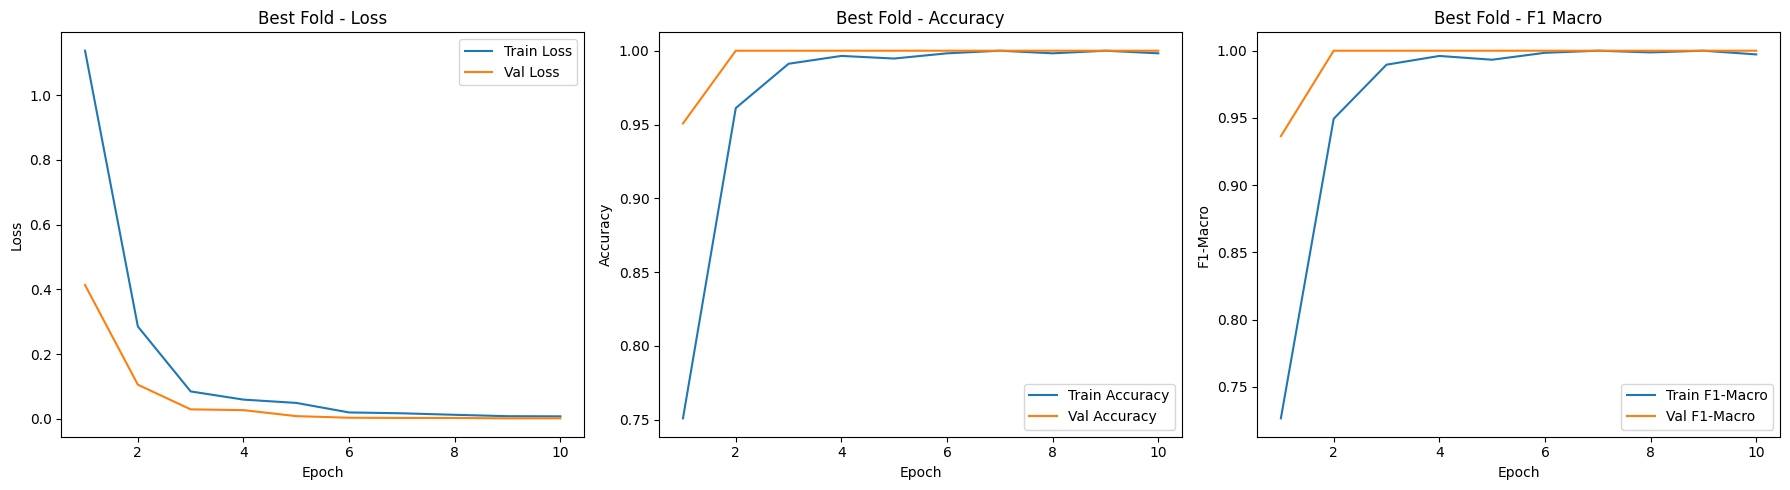

In [18]:
best_fold_num = best_model_info["fold"]

best_history = None
for item in all_fold_histories:
    if item["fold"] == best_fold_num:
        best_history = item["history"]
        break

epochs_range = range(1, len(best_history["train_loss"]) + 1)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs_range, best_history["train_loss"], label="Train Loss")
plt.plot(epochs_range, best_history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Best Fold - Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs_range, best_history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, best_history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Best Fold - Accuracy")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs_range, best_history["train_f1"], label="Train F1-Macro")
plt.plot(epochs_range, best_history["val_f1"], label="Val F1-Macro")
plt.xlabel("Epoch")
plt.ylabel("F1-Macro")
plt.title("Best Fold - F1 Macro")
plt.legend()

plt.tight_layout()
plt.show()

## Siapkan Test DataLoader

Membuat DataLoader untuk test set menggunakan `valid_transform` (tanpa augmentasi) agar evaluasi objektif.

In [19]:
test_loader = make_dataloader(test_df, valid_transform, shuffle=False)

## Evaluasi Final pada Test Set

Mengevaluasi model terbaik pada data test yang **sama sekali belum pernah dilihat** selama training.

**Hasil:**
- Test Loss: **0.0025** (sangat kecil)
- Test Accuracy: **100%**
- Test F1-Macro: **100%**

In [20]:
criterion_test = nn.CrossEntropyLoss()

test_loss, test_acc, test_f1, test_true, test_pred = eval_one_epoch(
    best_model, test_loader, criterion_test, DEVICE
)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test F1-Macro  : {test_f1:.4f}")

  0%|          | 0/15 [00:00<?, ?it/s]

Test Loss      : 0.0025
Test Accuracy  : 1.0000
Test F1-Macro  : 1.0000


## Classification Report

Laporan detail per kelas: precision, recall, dan F1-score.

Semua kelas mendapat nilai sempurna (1.0000), termasuk kelas minoritas seperti Naufal (55 gambar) dan Patrick (74 gambar).

In [21]:
report = classification_report(
    test_true,
    test_pred,
    target_names=class_names,
    digits=4
)
print(report)

              precision    recall  f1-score   support

       Ashif     1.0000    1.0000    1.0000        48
     Christo     1.0000    1.0000    1.0000        36
      Devian     1.0000    1.0000    1.0000        31
     Marcell     1.0000    1.0000    1.0000        42
      Naufal     1.0000    1.0000    1.0000        14
     Patrick     1.0000    1.0000    1.0000        19
       Satya     1.0000    1.0000    1.0000        47

    accuracy                         1.0000       237
   macro avg     1.0000    1.0000    1.0000       237
weighted avg     1.0000    1.0000    1.0000       237



## Confusion Matrix

Visualisasi matriks kesalahan prediksi. Diagonal penuh berarti **tidak ada satu pun gambar yang salah diklasifikasikan** pada test set.

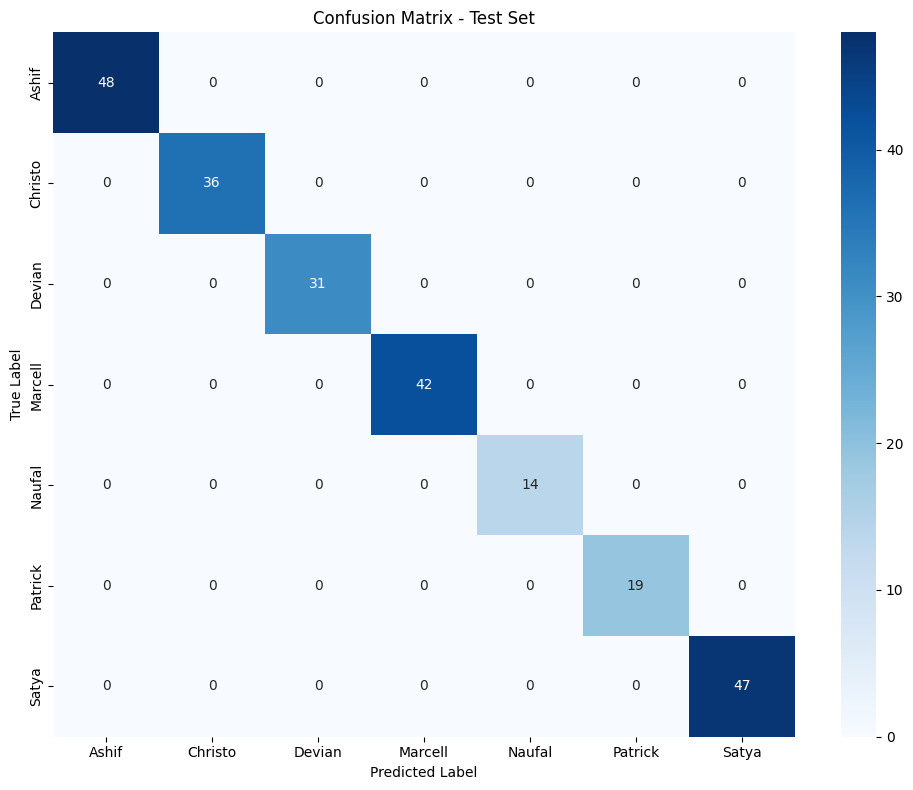

In [22]:
cm = confusion_matrix(test_true, test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## Simpan Model & Label Map

Menyimpan dua file untuk kebutuhan deployment:
- `best_face.pth` → bobot model PyTorch
- `label_map.json` → mapping nama kelas ke indeks angka

In [23]:
import json

torch.save(best_model, "best_face.pth")

with open("label_map.json", "w") as f:
    json.dump(class_to_idx, f)

print("Saved: best_face_full_model.pth")
print("Saved: label_map.json")

Saved: best_face_full_model.pth
Saved: label_map.json
